---
title: Fine-tuning Whisper
description: |
  Week 5 of the residency. How sound becomes something a transformer can read, and what a handful of gradient steps on one clip actually does.
author: Rosh Beed
date: '2026-07-06'
image: figures/slide-06.png
categories:
  - audio
  - speech
  - fine-tuning
  - week-5
jupyter: python3
---


Week 5 is titled *audio is all you need*, and its subtitle says what it's for:
adding another modality to our tool box.

Text was week 1. Images were week 3. The argument each time was that the
transformer doesn't care what the input was, as long as it arrives as a sequence
of vectors.

Audio is the third test of that claim.

Two tasks.

![](figures/slide-02.png){fig-alt="Task one: classify. An audio waveform, then the same clip as a spectrogram, with two routes labelled \"classify using a CNN\" and \"classify using a Transformer\", annotated \"clearly images :)\"."}

Note the annotation on that slide. Once audio is a spectrogram it's a
two-dimensional array of intensities. That's a picture, and the patch projection
from week 3 works on it unchanged.

![](figures/slide-03.png){fig-alt="Task two: fine-tune. Two audio clips and their spectrograms feeding a Base Whisper and a Tuned Whisper, both producing \"Hello, my name is Bes.\""}

The second task is the one this post follows, and there's the running example
again. *Hello, my name is Bes* was the sentence CBOW completed in week 1. Here a
speech model has to hear it.

## What Sound Is

![](figures/slide-11.png){fig-alt="Two waveforms, street music and a jackhammer, each beside the sine waves it decomposes into: 40, 220 and 300 Hz for the music, 700, 330 and 1500 Hz for the jackhammer."}

A waveform is amplitude over time, sampled 16,000 times a second, and almost none
of the structure a listener cares about is visible in it directly. Two different
sounds are two different bundles of vibrations at different frequencies.

![](figures/slide-12.png){fig-alt="A street-music waveform beside its frequency spectrum, magnitude against frequency."}

The Fourier transform unbundles it. Run it over short overlapping windows rather
than the whole clip and you get frequency on one axis, time on the other, intensity
as the value. That is the spectrogram, and it is why the previous slide could call
audio "clearly images".

Whisper adds two refinements.

* The frequency axis is squashed onto the **mel scale**. It spaces bands the way
  hearing does: fine detail low down, coarser high up. 80 bands replace 201 raw
  frequency bins.
* The values go through a **logarithm**, because loudness is perceived
  multiplicatively.

Below is that whole front end, built from scratch on the actual clip from the
project, so you can see the waveform go in and the picture come out.

In [1]:
#| warning: false

# Setup, inlined rather than imported so this notebook runs on its own.
# Keep it folded; nothing below it depends on anything outside this file.

import torch.nn as nn
import visualtorch
import matplotlib.pyplot as plt

# --- chart styling -------------------------------------------------------
# Categorical slots of a CVD-validated palette: blue, orange, aqua, purple.
COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#8a63d2"]
MUTED, GRID, AXIS = "#5b6570", "#e6e6e3", "#d5d5d1"


def style_axes(ax, xlabel=None, ylabel=None, grid="y"):
    """Strip an axes back to the ink that carries information."""
    if xlabel:
        ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    if grid:
        ax.grid(axis=grid, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    return ax


def figure(width=7.0, height=4.2, **kw):
    fig, ax = plt.subplots(figsize=(width, height), **kw)
    return fig, ax

# --- visualtorch, configured ---------------------------------------------
# Dropout is hidden: nn.TransformerEncoderLayer exposes its internal Dropout as a
# traceable leaf, every model here builds it with dropout=0.0, and drawing a no-op
# layer says it is part of the architecture when it is not. Uncoloured it also took
# visualtorch's default orange, near enough to MultiheadAttention's to be confusing.
COLOUR_MAP = {
    nn.Linear: {"fill": COLOURS[0]},
    nn.MultiheadAttention: {"fill": COLOURS[1]},
    nn.Embedding: {"fill": COLOURS[3]},
    nn.LayerNorm: {"fill": "#aeb6bf"},
    nn.GELU: {"fill": COLOURS[2]},
    nn.ReLU: {"fill": COLOURS[2]},
    nn.Flatten: {"fill": "#aeb6bf"},
    nn.Dropout: {"fill": "#e6e6e3"},
}
_COMMON = dict(color_map=COLOUR_MAP, connector_fill="#c3c9d0", background_fill="white",
               font_color=MUTED, legend=True, show_dimension=True,
               type_ignore=[nn.Dropout])


def diagram(model, input_shape, style="graph", **overrides):
    """Render `model` as a PIL image in this site's colours.

    `graph` draws real neurons and suits a short stack; `flow` draws volumetric
    blocks whose size tracks the layer's and stays readable on a deep one. `flow`
    reports a 3-D activation as (1, 1, width), losing the sequence length, so its
    shape labels are off. `level_gap=1` keeps a residual connection drawn close to
    the blocks it skips.
    """
    if style == "graph":
        settings = dict(node_size=24, layer_spacing=110, node_spacing=8,
                        ellipsize_after=5, **_COMMON)
    else:
        settings = dict(spacing=26, scale_xy=2.4, max_xy=280, one_dim_orientation="y",
                        level_gap=1, **_COMMON)
        settings["show_dimension"] = False
    settings.update(overrides)
    return visualtorch.render(model, input_shape=input_shape, style=style, **settings)

# --- the log-mel picture -------------------------------------------------
DYNAMIC_RANGE = 8.0      # Whisper clamps the quiet end this far below the loudest


def log_mel(x, bank, n_fft, hop):
    """A waveform in, a log-mel picture out, time down the rows."""
    power = np.abs(stft(x, n_fft, hop)) ** 2
    picture = np.log10(np.maximum(bank @ power, 1e-10))
    return np.maximum(picture, picture.max() - DYNAMIC_RANGE).T.astype(np.float32)


import numpy as np
from huggingface_hub import hf_hub_download

REVISION = "f705fed08827ff6c36e3b5329495c943a5e544e8"
clip = np.load(hf_hub_download("roshbeed/ai-residency-blog-data", "audio/clip-16k.npz",
                               repo_type="dataset", revision=REVISION))
waveform, rate = clip["waveform"], int(clip["sample_rate"])

N_FFT, HOP, N_MELS = 400, 160, 80

def stft(x, n_fft, hop):
    """Fourier transform of each short overlapping window."""
    window = np.hanning(n_fft + 1)[:-1]
    frames = 1 + (len(x) - n_fft) // hop
    return np.stack([np.fft.rfft(x[i * hop:i * hop + n_fft] * window)
                     for i in range(frames)], axis=1)

def mel_filterbank(rate, n_fft, n_mels):
    """Triangular filters, evenly spaced on the mel scale rather than in hertz."""
    to_mel = lambda f: 2595 * np.log10(1 + f / 700)
    to_hz = lambda m: 700 * (10 ** (m / 2595) - 1)
    edges = to_hz(np.linspace(to_mel(0), to_mel(rate / 2), n_mels + 2))

    # The actual frequency of each FFT bin. Rounding the triangle corners to whole
    # bins instead is the tempting shortcut, and down here the mel bands are
    # narrower than one bin is wide, so several of them round onto the same corner
    # and come out empty.
    freqs = np.linspace(0, rate / 2, n_fft // 2 + 1)

    bank = np.zeros((n_mels, len(freqs)))
    for m in range(n_mels):
        left, centre, right = edges[m], edges[m + 1], edges[m + 2]
        rising = (freqs - left) / (centre - left)
        falling = (right - freqs) / (right - centre)
        bank[m] = np.maximum(0.0, np.minimum(rising, falling))
        bank[m] *= 2.0 / (right - left)     # equal area, so a wide band cannot shout
    return bank

bank = mel_filterbank(rate, N_FFT, N_MELS)
print(f"{N_MELS} filters over {bank.shape[1]} frequency bins, "
      f"{(bank.sum(1) == 0).sum()} of them empty")
spans = np.count_nonzero(bank, axis=1)
print(f"the narrowest covers {spans.min()} frequency bin, the widest {spans.max()}")


80 filters over 201 frequency bins, 0 of them empty
the narrowest covers 1 frequency bin, the widest 14


/Users/rosh/mlx/roshbeed.github.io/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Every band carries signal, and the low ones are narrow where the high ones are
wide. That spacing is what the mel scale is for. Now push the clip through them.

In [2]:
power = np.abs(stft(waveform, N_FFT, HOP)) ** 2
picture = np.log10(np.maximum(bank @ power, 1e-10))

# Whisper clamps the quiet end to 8 log units below the loudest point. Without it
# the floor above sets the bottom of the colour scale at -10 and every real value
# is squashed into the top of the range.
picture = np.maximum(picture, picture.max() - 8.0)

print(f"{len(waveform):,} samples at {rate} Hz = {len(waveform) / rate:.2f} seconds")
print(f"becomes an {picture.shape[0]} by {picture.shape[1]} picture, "
      f"values from {picture.min():.1f} to {picture.max():.1f}")

16,982 samples at 16000 Hz = 1.06 seconds
becomes an 80 by 104 picture, values from -6.9 to 1.1


A second of sound, 17,000 numbers long, comes out as an 80 by 104 grid. That grid
is what the model reads.

Drawn, the waveform and the picture it becomes:

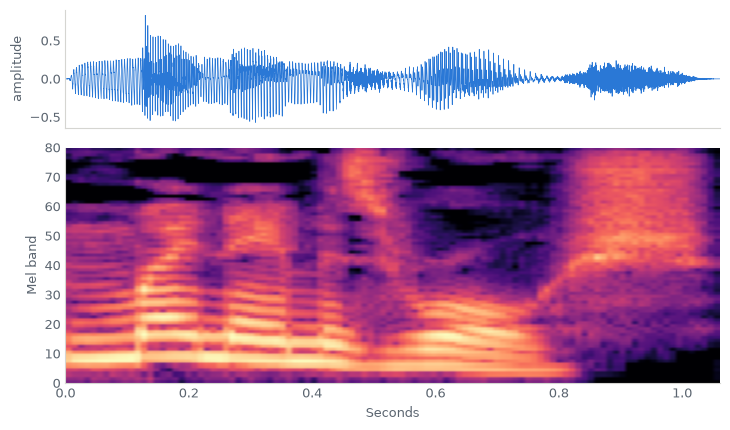

In [3]:
#| label: fig-mel
#| fig-cap: One second of speech, before and after. The model never sees the waveform on top.
#| fig-alt: A waveform above, and below it a spectrogram. The lower mel bands are brightest, with a stack of evenly spaced horizontal lines running through the middle of the picture that bend and break as the speech changes.

import matplotlib.pyplot as plt

fig, (top, bottom) = plt.subplots(2, 1, figsize=(7.4, 4.4),
                                  gridspec_kw={"height_ratios": [1, 2]})
top.plot(np.arange(len(waveform)) / rate, waveform, color=COLOURS[0], linewidth=0.5)
top.set_xlim(0, len(waveform) / rate)
style_axes(top, ylabel="amplitude", grid=None)
top.set_xticks([])
bottom.imshow(picture, aspect="auto", origin="lower", cmap="magma",
              extent=(0, len(waveform) / rate, 0, N_MELS))
style_axes(bottom, "Seconds", "Mel band", grid=None)
fig.tight_layout()

## Whisper

![](figures/slide-06.png){fig-alt="Whisper's architecture: a log-mel spectrogram through two convolutions and sinusoidal positional encoding into transformer encoder blocks, with transformer decoder blocks cross-attending to them and producing tokens."}

An encoder over the spectrogram, a decoder cross-attending to it. Structurally this
is [week 3's multi-digit reader](../2026-06-25-encoder-decoder-transformers/) with a
spectrogram where the image was, which is the claim the week set out to test.

The two convolutions at the front are doing something worth noticing: the second
has stride 2, halving the sequence from 3000 positions to 1500. Attention cost
grows with the square of sequence length, so that one layer is a four-fold saving
before any attention runs.

And a Whisper transcript does not start with words. It starts with a structured
token prefix, which is how one model handles transcription, translation and
language identification without being three models. For the running example that prefix is `<|startoftranscript|><|en|><|transcribe|><|notimestamps|>`,
and the words follow it.

## Fine-tuning on One Example

![](figures/slide-14.png){fig-alt="Tune result: the baseline transcription \"Hello, my name is Bess.\" against the target \"Hello, my name is Bes.\", with target and output token ids and the loss falling from 0.5395 to 0.1766."}

The base model mishears the name. Bess, with two esses.

The workshop's demonstration is to fine-tune on that one clip and watch it correct,
which makes the mechanism visible in a way a held-out score never does. It also
makes something else visible, which is what the rest of this post measures.

I cannot run Whisper here. What follows is the same shape at a size
that trains in seconds.

The language is synthetic. Each letter is a tone at its own frequency, and words are
three letters long. Speaking a word plays its tones in order. Transcribing reads
them back, through the same spectrogram front end as above.

In [4]:
import torch
import torch.nn as nn

# Re-running this page must reproduce it, so a result that shifts between runs would let
# the prose and the output disagree. Torch's multithreaded CPU reductions add floats
# in whatever order the threads finish in; over a training loop that compounds into a
# different model. One thread makes the run reproducible.
torch.set_num_threads(1)

RATE, TONE_SECONDS, NOISE = 8000, 0.08, 0.15
ALPHABET = "abcdefgh"
TONES = {c: 300 * 1.28 ** i for i, c in enumerate(ALPHABET)}

rng = np.random.default_rng(0)
WORDS = sorted({"".join(rng.choice(list(ALPHABET), 3)) for _ in range(60)})[:40]

def speak(word, seed, shift=1.0):
    g = np.random.default_rng(seed)
    parts = []
    for c in word:
        t = np.arange(int(RATE * TONE_SECONDS)) / RATE
        f = TONES[c] * shift * (1 + 0.02 * g.normal())
        parts.append((np.sin(2 * np.pi * f * t) + 0.4 * np.sin(4 * np.pi * f * t))
                     * np.hanning(len(t)))
    x = np.concatenate(parts)
    return (x + NOISE * g.normal(size=len(x))).astype(np.float32)

print(f"{len(ALPHABET)} letters, each a tone:")
print("  " + ", ".join(f"{c} = {TONES[c]:.0f} Hz" for c in ALPHABET))
shown = [WORDS[i] for i in (0, len(WORDS) // 3, 2 * len(WORDS) // 3, -1)]
print(f"{len(WORDS)} words of three letters: {', '.join(repr(w) for w in shown[:-1])} "
      f"and so on to {shown[-1]!r}")


8 letters, each a tone:
  a = 300 Hz, b = 384 Hz, c = 492 Hz, d = 629 Hz, e = 805 Hz, f = 1031 Hz, g = 1319 Hz, h = 1689 Hz
40 words of three letters: 'aaa', 'cca', 'ecc' and so on to 'ffe'


Each letter a step up in pitch, each word three of them in a row. Through the same
front end as the real clip above, a word becomes a small picture:

In [5]:
SMALL_FFT, SMALL_HOP, SMALL_MELS = 256, 64, 32
BANK = mel_filterbank(RATE, SMALL_FFT, SMALL_MELS)

# The same front end as above, at the size this toy needs.

to_picture = lambda x: log_mel(x, BANK, SMALL_FFT, SMALL_HOP)

def build(repeats, seed0):
    pictures, labels = [], []
    for index, word in enumerate(WORDS):
        for k in range(repeats):
            pictures.append(to_picture(speak(word, seed0 + index * 1000 + k)))
            labels.append(index)
    return torch.from_numpy(np.stack(pictures)), torch.tensor(labels)

X, Y = build(12, 0)
X_test, Y_test = build(4, 500_000)
print(f"{len(WORDS)} words, {len(X)} training clips of shape {tuple(X.shape[1:])}")

40 words, 480 training clips of shape (27, 32)


The model is an encoder over the spectrogram and a decoder that spells the word,
which is Whisper's shape at about a thousandth of the size. Trained for twenty
epochs it gets nearly everything right.

In [6]:
#| warning: false

LETTERS = sorted(set("".join(WORDS)))
START, END = len(LETTERS), len(LETTERS) + 1
VOCAB = len(LETTERS) + 2
DIM, FRAMES = 64, X.shape[1]
TARGET = torch.tensor([[START] + [LETTERS.index(c) for c in w] + [END] for w in WORDS])

class Transcriber(nn.Module):
    def __init__(self):
        super().__init__()
        self.input = nn.Linear(SMALL_MELS, DIM)
        self.audio_positions = nn.Parameter(torch.randn(1, FRAMES, DIM) * 0.02)
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(DIM, 4, 4 * DIM, batch_first=True,
                                       norm_first=True, dropout=0.0), 2)
        self.embed = nn.Embedding(VOCAB, DIM)
        self.text_positions = nn.Parameter(torch.randn(1, 5, DIM) * 0.02)
        self.decoder = nn.TransformerDecoder(
            nn.TransformerDecoderLayer(DIM, 4, 4 * DIM, batch_first=True,
                                       norm_first=True, dropout=0.0), 2)
        self.out = nn.Linear(DIM, VOCAB)

    def forward(self, picture, tokens):
        memory = self.encoder(self.input(picture) + self.audio_positions)
        h = self.embed(tokens) + self.text_positions[:, :tokens.shape[1]]
        mask = nn.Transformer.generate_square_subsequent_mask(tokens.shape[1])
        return self.out(self.decoder(h, memory, tgt_mask=mask))


Two encoder layers over the picture, two decoder layers spelling the word out, and
a vocabulary of eight letters plus a start and an end token. Twenty epochs of it:

In [7]:
torch.manual_seed(0)
model = Transcriber()
optimiser = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
generator = torch.Generator().manual_seed(0)

@torch.no_grad()
def transcribe(pictures):
    tokens = torch.full((len(pictures), 1), START)
    for _ in range(3):
        tokens = torch.cat([tokens, model(pictures, tokens)[:, -1].argmax(-1, keepdim=True)], 1)
    return tokens[:, 1:]

spell = lambda ids: "".join(LETTERS[i] for i in ids if i < len(LETTERS))
accuracy = lambda: (transcribe(X_test) == TARGET[Y_test][:, 1:4]).all(1).float().mean().item()

for epoch in range(20):
    perm = torch.randperm(len(X), generator=generator)
    for i in range(0, len(perm) - 64, 64):
        b = perm[i:i + 64]
        target = TARGET[Y[b]]
        loss = nn.functional.cross_entropy(model(X[b], target[:, :-1]).reshape(-1, VOCAB),
                                           target[:, 1:].reshape(-1))
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

print(f"transcribes {accuracy():.1%} of held-out clips exactly right")

/var/folders/rz/2164hm0x2cv9dcqz41x_4l640000gn/T/ipykernel_91955/1460192895.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


transcribes 99.4% of held-out clips exactly right


Drawn out, it is the encoder-decoder shape again:

/var/folders/rz/2164hm0x2cv9dcqz41x_4l640000gn/T/ipykernel_91955/1460192895.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


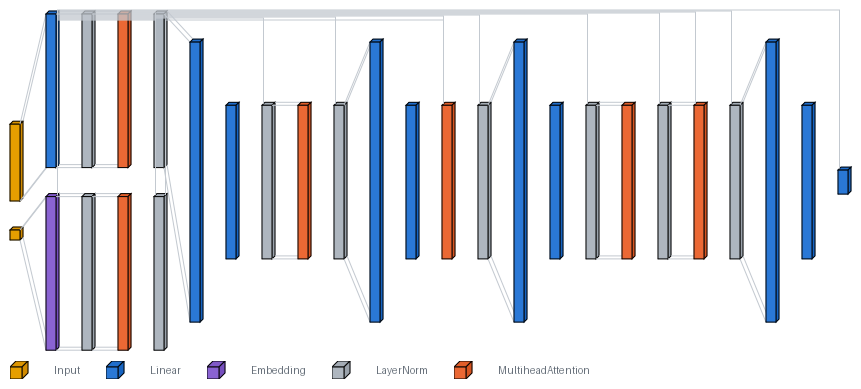

In [8]:
#| label: fig-arch
#| warning: false
#| fig-cap: Whisper's shape at about a thousandth of the size. The spectrogram enters top left, the text so far enters bottom left through its embedding, and the two streams meet in the decoder.
#| fig-alt: A diagram with two input streams on the left, one from the spectrogram and one through an embedding, converging into a single output column.

diagram(Transcriber(), input_shape=((1, FRAMES, SMALL_MELS), (1, 4)), style="flow",
        input_dtype=(torch.float32, torch.long))

Now it needs its own version of mishearing a name. Say one word with every tone
shifted up 10%, which is a voice it has never encountered, and it gets it wrong.

In [9]:
WORD, SHIFT = "acd", 1.10
one_clip = torch.from_numpy(to_picture(speak(WORD, 999, SHIFT))).unsqueeze(0)
one_target = TARGET[WORDS.index(WORD)].unsqueeze(0)

print(f"the word is {WORD!r}")
print(f"the model hears {spell(transcribe(one_clip)[0].tolist())!r}")
print(f"and is otherwise fine: {accuracy():.1%} on the clean test clips")

the word is 'acd'
the model hears 'adc'
and is otherwise fine: 99.4% on the clean test clips


That's the situation the workshop demonstration is in: a model that works, and one
specific thing it gets wrong. Fine-tune on that single clip and watch both numbers
at once: the loss on the clip, and accuracy on everything else.

In [10]:
fine_tune = torch.optim.AdamW(model.parameters(), lr=1e-4)

print(f"{'step':>5} {'loss':>10} {'hears':>8} {'clean accuracy':>16}")
print(f"{0:>5} {'-':>10} {spell(transcribe(one_clip)[0].tolist()):>8} {accuracy():>15.1%}")

steps, losses, clean = [], [], []
for step in range(1, 13):
    loss = nn.functional.cross_entropy(
        model(one_clip, one_target[:, :-1]).reshape(-1, VOCAB), one_target[:, 1:].reshape(-1))
    fine_tune.zero_grad()
    loss.backward()
    fine_tune.step()

    steps.append(step); losses.append(loss.item()); clean.append(accuracy())
    if step % 2 == 0:
        print(f"{step:>5} {loss.item():>10.5f} {spell(transcribe(one_clip)[0].tolist()):>8} "
              f"{clean[-1]:>15.1%}")

 step       loss    hears   clean accuracy
    0          -      adc           99.4%
    2    0.47773      acd           99.4%


    4    0.04301      acd           98.8%


    6    0.02471      acd           94.4%
    8    0.03178      acd           93.8%


   10    0.02131      acd           93.8%


   12    0.01366      acd           91.9%


Two steps and it says the word correctly. The loss keeps falling after that, and
the right-hand column is what it costs: seven and a half points of accuracy on the
thirty-nine words nobody asked it to change.

Both numbers on one chart, the clip's loss against everything else's accuracy:

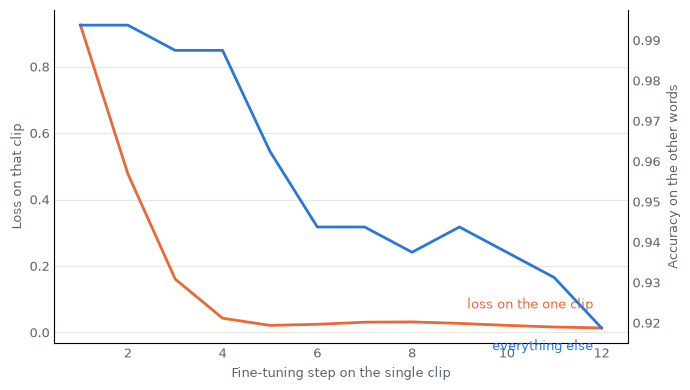

In [11]:
#| label: fig-forget
#| fig-cap: The fix lands almost immediately. Everything after that is the model memorising one clip at the expense of the other thirty-nine words.
#| fig-alt: Two lines over twelve steps. The loss falls sharply to near zero within four steps; the clean accuracy line holds briefly then declines steadily.

fig, ax = figure(height=4.0)
ax.plot(steps, losses, color=COLOURS[1], linewidth=2)
style_axes(ax, "Fine-tuning step on the single clip", "Loss on that clip")
ax.annotate("loss on the one clip", xy=(steps[-1], losses[-1]), xytext=(-6, 14),
            textcoords="offset points", ha="right", fontsize=9, color=COLOURS[1])

right = ax.twinx()
right.plot(steps, clean, color=COLOURS[0], linewidth=2)
right.set_ylabel("Accuracy on the other words", color=MUTED, fontsize=9)
right.tick_params(colors=MUTED, labelsize=9, length=0)
right.spines["top"].set_visible(False)
right.annotate("everything else", xy=(steps[-1], clean[-1]), xytext=(-6, -16),
               textcoords="offset points", ha="right", fontsize=9, color=COLOURS[0])
fig.tight_layout()

The fix is cheap: two gradient steps and the word is right. On the real project a
handful of steps corrected the name.

The loss then falls to nearly zero. That looks like good news. It's not.

With one training example, a loss near zero means the model has memorised that clip.
It's precisely what you asked for. It's also what quietly goes wrong when the same
procedure is scaled up.

And the cost lands somewhere nobody is looking. Accuracy on the other thirty-nine
words falls steadily from step four, and by step twelve the model has given up
seven and a half points to keep improving on a clip it already got right. Nothing in the
fine-tuning loop reports that.

So the question isn't whether fine-tuning works. It's when to stop. Answering that
means evaluating the thing you aren't training on.

## Conclusion

* A spectrogram turns sound into a picture, and week 3's machinery then applies
* Whisper is an encoder-decoder over that picture
* Fine-tuning on one example works, and works fast
* It also costs you accuracy everywhere else, and nothing reports that
* Measure what you are not training on

One Whisper-specific trap, which produced no error at all. The tokenizer emits
`<|startoftranscript|>` at the front of a transcript, and it is tempting to pass its
output straight through as labels. The model prepends `decoder_start_token_id`
itself when it shifts labels right, and that token *is* start-of-transcript, so
every position ends up one out of step. Nothing raises, the loss goes down, and the
model learns a different task from the one you meant.

The full project is
[on GitHub](https://github.com/RoshBeed/ai-residency/tree/main/services/whisper-fine-tuning).
